# Pengambilan Material

In [5]:
# Materials Project API
API_KEY = "czPKGKOpzKKAvEin6xXMyLnBRSVKzsbE"


In [29]:
from mp_api.client import MPRester
import pandas as pd
import random
import pickle

random.seed(42)

FIELDS = [
    "material_id",
    "formula_pretty",
    "band_gap",
    "formation_energy_per_atom",
    "is_metal",
    "nsites",
    "structure"
]

with MPRester(API_KEY) as mpr:

    print("Mengambil data metal...")

    metal = list(
        mpr.materials.summary.search(
            is_metal=True,
            fields=FIELDS,
            chunk_size=1000,
            num_chunks=5
        )
    )

    print("Metal ditemukan:", len(metal))

    print("Mengambil data semimetal...")

    semimetal = list(
        mpr.materials.summary.search(
            band_gap=(0.0, 0.5),
            is_metal=False,
            fields=FIELDS,
            chunk_size=1000,
            num_chunks=5
        )
    )

    print("Semimetal ditemukan:", len(semimetal))

    print("Mengambil data semiconductor...")

    semiconductor = list(
        mpr.materials.summary.search(
            band_gap=(0.5, 3.0),
            is_metal=False,
            fields=FIELDS,
            chunk_size=1000,
            num_chunks=5
        )
    )

    print("Semiconductor ditemukan:", len(semiconductor))

Mengambil data metal...


Retrieving SummaryDoc documents:   0%|          | 0/5000 [00:00<?, ?it/s]

Metal ditemukan: 5000
Mengambil data semimetal...


Retrieving SummaryDoc documents:   0%|          | 0/5000 [00:00<?, ?it/s]

Semimetal ditemukan: 5000
Mengambil data semiconductor...


Retrieving SummaryDoc documents:   0%|          | 0/5000 [00:00<?, ?it/s]

Semiconductor ditemukan: 5000


# Energi Pembentukan 

In [30]:
metal = random.sample(
    metal,
    min(2000, len(metal))
)

semimetal = random.sample(
    semimetal,
    min(2000, len(semimetal))
)

semiconductor = random.sample(
    semiconductor,
    min(2000, len(semiconductor))
)

materials = metal + semimetal + semiconductor

print("Total material:", len(materials))

Total material: 6000


In [32]:
rows = []

for m in materials:

    try:

        rows.append({
            "material_id": str(m.material_id),
            "formula": m.formula_pretty,
            "band_gap": float(m.band_gap),
            "formation_energy": float(
                m.formation_energy_per_atom
            ),
            "is_metal": bool(m.is_metal),
            "nsites": int(m.nsites),
            "structure": m.structure
        })

    except Exception:
        pass

df = pd.DataFrame(rows)

df.head()

,material_id,formula,band_gap,formation_energy,is_metal,nsites,structure
0,mp-676414,Al4CO,0.0,-0.587042,True,6,[[3.57781860e-03 3.94083151e+00 3.11930310e+00...
1,mp-865953,AcYbZn2,0.0,-0.242078,True,4,"[[3.71742369 3.71742369 3.71742369] Ac, [0. 0...."
2,mp-1026819,BaLiMg14,0.0,0.097091,True,16,[[3.33651295e-06 1.92633450e+00 6.53714443e+00...
3,mp-1104205,BaErFe4O7,0.0,-2.193267,True,13,[[3.16664800e+00 2.22044605e-16 2.32347650e+00...
4,mp-1229149,Ba10Er5Cu15O34,0.0,-2.204054,True,64,"[[3.2738032 6.09321347 9.6073013 ] Ba, [-0.09..."


In [11]:
print(df.columns)

# material_id
# formula
# band_gap
# formation_energy

Index(['material_id', 'formula', 'band_gap', 'formation_energy', 'fe_bin'], dtype='object')


In [33]:
print(df.describe())

print("\nMetal:")
print(df["is_metal"].value_counts())

print("\nBand Gap:")
print(df["band_gap"].describe())

print("\nFormation Energy:")
print(df["formation_energy"].describe())

          band_gap  formation_energy       nsites
count  6000.000000       6000.000000  6000.000000
mean      0.638398         -1.509291    30.870333
std       0.868652          1.202600    29.661628
min       0.000000         -4.287387     1.000000
25%       0.000000         -2.454601    10.000000
50%       0.191350         -1.668458    22.000000
75%       1.103275         -0.573000    40.000000
max       2.998700          4.347515   336.000000

Metal:
is_metal
False    4000
True     2000
Name: count, dtype: int64

Band Gap:
count    6000.000000
mean        0.638398
std         0.868652
min         0.000000
25%         0.000000
50%         0.191350
75%         1.103275
max         2.998700
Name: band_gap, dtype: float64

Formation Energy:
count    6000.000000
mean       -1.509291
std         1.202600
min        -4.287387
25%        -2.454601
50%        -1.668458
75%        -0.573000
max         4.347515
Name: formation_energy, dtype: float64


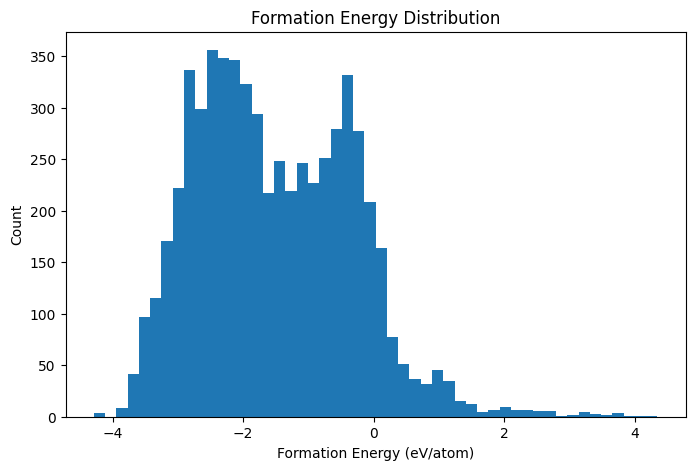

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    df["formation_energy"],
    bins=50
)

plt.xlabel("Formation Energy (eV/atom)")
plt.ylabel("Count")
plt.title("Formation Energy Distribution")

plt.show()

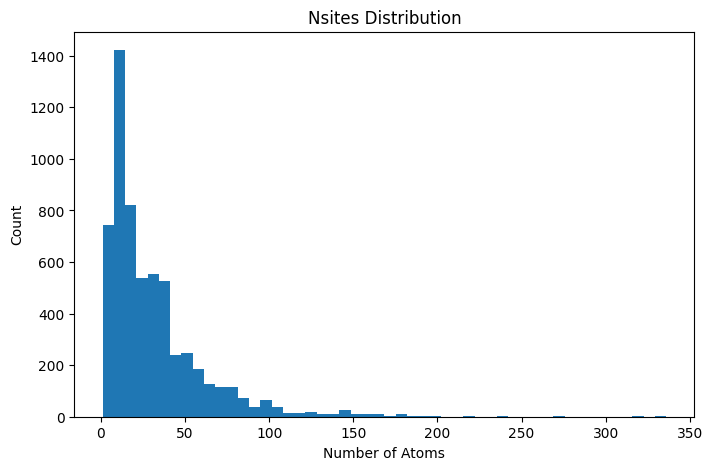

In [35]:
plt.figure(figsize=(8,5))

plt.hist(
    df["nsites"],
    bins=50
)

plt.xlabel("Number of Atoms")
plt.ylabel("Count")
plt.title("Nsites Distribution")

plt.show()

In [36]:
df = df[
    (df["formation_energy"] > -8)
    &
    (df["formation_energy"] < 2)
]

df = df[
    df["nsites"] <= 200
]

df = df.reset_index(drop=True)

print(df.shape)

(5938, 7)


In [38]:
print(df["formation_energy"].describe())

print(df["nsites"].describe())

count    5938.000000
mean       -1.548855
std         1.135122
min        -4.287387
25%        -2.460488
50%        -1.688203
75%        -0.605758
max         1.944946
Name: formation_energy, dtype: float64
count    5938.00000
mean       30.77804
std        28.49284
min         1.00000
25%        11.00000
50%        22.00000
75%        40.00000
max       200.00000
Name: nsites, dtype: float64


In [39]:
with open(
    "formation_energy_dataset.pkl",
    "wb"
) as f:

    pickle.dump(df, f)

print("Dataset disimpan.")

Dataset disimpan.


In [40]:
with open(
    "formation_energy_dataset.pkl",
    "rb"
) as f:

    df = pickle.load(f)

print(df.head())

  material_id         formula  band_gap  formation_energy  is_metal  nsites  \
0   mp-676414           Al4CO       0.0         -0.587042      True       6   
1   mp-865953         AcYbZn2       0.0         -0.242078      True       4   
2  mp-1026819        BaLiMg14       0.0          0.097091      True      16   
3  mp-1104205       BaErFe4O7       0.0         -2.193267      True      13   
4  mp-1229149  Ba10Er5Cu15O34       0.0         -2.204054      True      64   

                                           structure  
0  [[3.57781860e-03 3.94083151e+00 3.11930310e+00...  
1  [[3.71742369 3.71742369 3.71742369] Ac, [0. 0....  
2  [[3.33651295e-06 1.92633450e+00 6.53714443e+00...  
3  [[3.16664800e+00 2.22044605e-16 2.32347650e+00...  
4  [[3.2738032  6.09321347 9.6073013 ] Ba, [-0.09...  


In [41]:
print(df.shape)

print(df["formation_energy"].describe())

print(df["nsites"].describe())

(5938, 7)
count    5938.000000
mean       -1.548855
std         1.135122
min        -4.287387
25%        -2.460488
50%        -1.688203
75%        -0.605758
max         1.944946
Name: formation_energy, dtype: float64
count    5938.00000
mean       30.77804
std        28.49284
min         1.00000
25%        11.00000
50%        22.00000
75%        40.00000
max       200.00000
Name: nsites, dtype: float64


In [43]:
print(df["formation_energy"].describe())

print("\nSkewness:")
print(df["formation_energy"].skew())

print("\nKurtosis:")
print(df["formation_energy"].kurt())

count    5938.000000
mean       -1.548855
std         1.135122
min        -4.287387
25%        -2.460488
50%        -1.688203
75%        -0.605758
max         1.944946
Name: formation_energy, dtype: float64

Skewness:
0.2729316667553945

Kurtosis:
-0.6959548397468533


In [44]:
def material_type(row):

    if row["is_metal"]:
        return "Metal"

    elif row["band_gap"] <= 0.5:
        return "Semimetal"

    else:
        return "Semiconductor"


df["material_type"] = df.apply(
    material_type,
    axis=1
)

print(df["material_type"].value_counts())

material_type
Semiconductor    1991
Metal            1985
Semimetal        1962
Name: count, dtype: int64


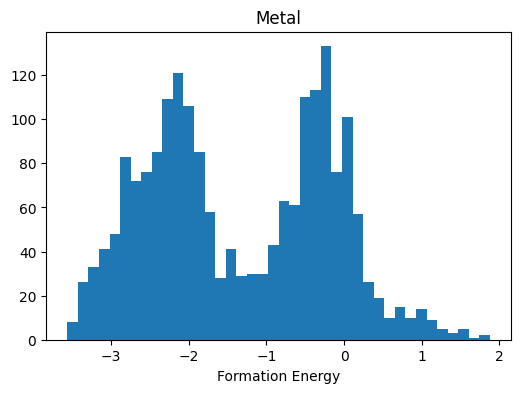

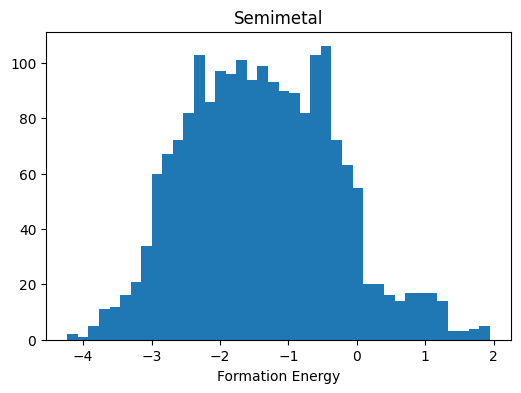

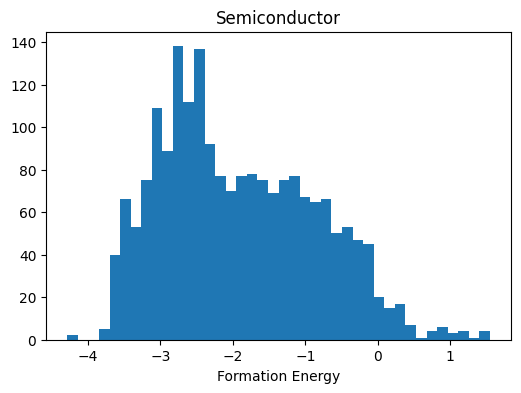

In [45]:
import matplotlib.pyplot as plt

for cat in df["material_type"].unique():

    plt.figure(figsize=(6,4))

    subset = df[
        df["material_type"] == cat
    ]

    plt.hist(
        subset["formation_energy"],
        bins=40
    )

    plt.title(cat)

    plt.xlabel(
        "Formation Energy"
    )

    plt.show()

<Figure size 800x500 with 0 Axes>

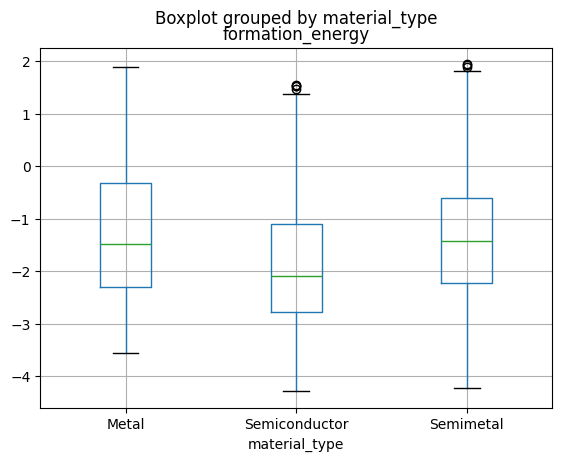

In [46]:
plt.figure(figsize=(8,5))

df.boxplot(
    column="formation_energy",
    by="material_type"
)

plt.show()

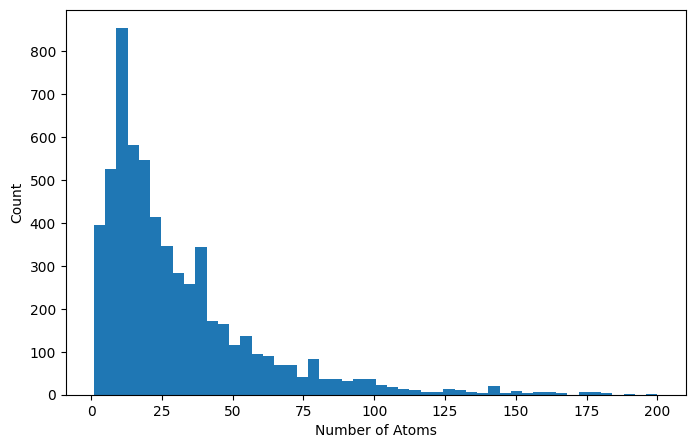

In [47]:
plt.figure(figsize=(8,5))

plt.hist(
    df["nsites"],
    bins=50
)

plt.xlabel("Number of Atoms")
plt.ylabel("Count")

plt.show()

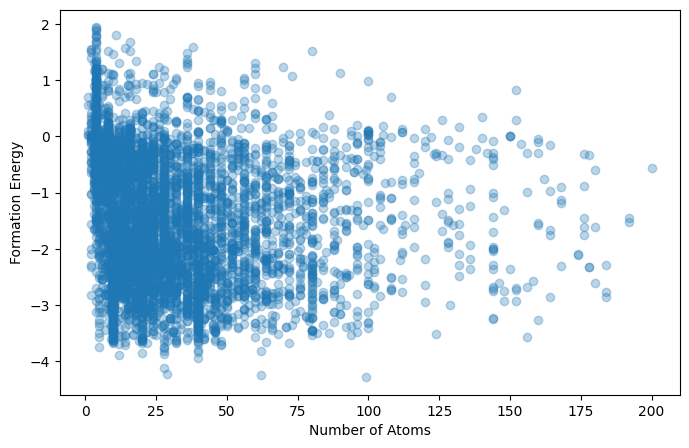

In [48]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["nsites"],
    df["formation_energy"],
    alpha=0.3
)

plt.xlabel("Number of Atoms")
plt.ylabel("Formation Energy")

plt.show()

In [49]:
bins = [
    -5,
    -3,
    -2,
    -1,
    0,
    1,
    2
]

df["fe_bin"] = pd.cut(
    df["formation_energy"],
    bins=bins
)

print(
    df["fe_bin"].value_counts()
)

fe_bin
(-3, -2]    1872
(-1, 0]     1519
(-2, -1]    1472
(-5, -3]     551
(0, 1]       434
(1, 2]        90
Name: count, dtype: int64


In [50]:
numeric_cols = [
    "band_gap",
    "formation_energy",
    "nsites"
]

corr = df[
    numeric_cols
].corr()

print(corr)

                  band_gap  formation_energy    nsites
band_gap          1.000000         -0.266986  0.130514
formation_energy -0.266986          1.000000 -0.104665
nsites            0.130514         -0.104665  1.000000


In [51]:
print("="*50)

print("Jumlah Material")
print(len(df))

print("\nFormation Energy")
print(df["formation_energy"].describe())

print("\nBand Gap")
print(df["band_gap"].describe())

print("\nNsites")
print(df["nsites"].describe())

print("="*50)

Jumlah Material
5938

Formation Energy
count    5938.000000
mean       -1.548855
std         1.135122
min        -4.287387
25%        -2.460488
50%        -1.688203
75%        -0.605758
max         1.944946
Name: formation_energy, dtype: float64

Band Gap
count    5938.000000
mean        0.642148
std         0.870810
min         0.000000
25%         0.000000
50%         0.194364
75%         1.110575
max         2.998700
Name: band_gap, dtype: float64

Nsites
count    5938.00000
mean       30.77804
std        28.49284
min         1.00000
25%        11.00000
50%        22.00000
75%        40.00000
max       200.00000
Name: nsites, dtype: float64


# GRAPH FOCUS

In [52]:
import torch
import pickle
import numpy as np

from torch_geometric.data import Data

from pymatgen.analysis.local_env import CrystalNN
from pymatgen.core.periodic_table import Element

In [53]:
cnn = CrystalNN(
    distance_cutoffs=None,
    x_diff_weight=0,
    porous_adjustment=False
)

In [54]:
def atom_features(site):

    elem = Element(site.specie.symbol)

    atomic_radius = elem.atomic_radius or 0
    ionic_radius = elem.average_ionic_radius or 0
    calc_radius = elem.atomic_radius_calculated or 0

    en = elem.X or 0

    try:
        max_ox = max(elem.common_oxidation_states)
    except:
        max_ox = 0

    try:
        min_ox = min(elem.common_oxidation_states)
    except:
        min_ox = 0

    try:
        valence = elem.nvalence()
    except:
        valence = 0

    try:
        outer_e = elem.full_electronic_structure[-1][2]
    except:
        outer_e = 0

    return [

        elem.Z / 100,
        float(elem.atomic_mass) / 300,

        en / 4,

        elem.group / 18,
        elem.row / 7,

        atomic_radius / 3,
        ionic_radius / 2,
        calc_radius / 3,

        (elem.mendeleev_no or 0) / 120,

        valence / 12,
        outer_e / 14,

        max_ox / 8,
        min_ox / 8,

        1 if elem.block == "s" else 0,
        1 if elem.block == "p" else 0,
        1 if elem.block == "d" else 0,
        1 if elem.block == "f" else 0,

        1 if elem.is_metal else 0,

        1 if elem.is_transition_metal else 0
    ]

In [55]:
def structure_to_graph(structure, formation_energy):

    x = torch.tensor(
        [atom_features(site) for site in structure],
        dtype=torch.float
    )

    edge_index = []
    edge_attr = []

    for i in range(len(structure)):

        try:

            neighbors = cnn.get_nn_info(
                structure,
                i
            )

            coord_num = len(neighbors)

            elem_i = Element(
                structure[i].specie.symbol
            )

            chi_i = elem_i.X or 0
            rad_i = elem_i.atomic_radius or 0

            for nn in neighbors:

                j = nn["site_index"]

                elem_j = Element(
                    structure[j].specie.symbol
                )

                chi_j = elem_j.X or 0
                rad_j = elem_j.atomic_radius or 0

                distance = structure.get_distance(
                    i,
                    j
                )

                edge_index.append(
                    [i, j]
                )

                edge_attr.append([

                    distance,

                    nn["weight"],

                    abs(
                        chi_i - chi_j
                    ),

                    abs(
                        rad_i - rad_j
                    ),

                    (chi_i + chi_j) / 2,

                    (rad_i + rad_j) / 2,

                    coord_num
                ])

        except:
            continue

    if len(edge_index) == 0:

        return None

    edge_index = torch.tensor(
        edge_index,
        dtype=torch.long
    ).t().contiguous()

    edge_attr = torch.tensor(
        edge_attr,
        dtype=torch.float
    )

    y = torch.tensor(
        [formation_energy],
        dtype=torch.float
    )

    graph = Data(
        x=x,
        edge_index=edge_index,
        edge_attr=edge_attr,
        y=y
    )

    return graph

In [56]:
graph_dataset = []

failed = 0

for idx, row in df.iterrows():

    try:

        graph = structure_to_graph(
            row["structure"],
            row["formation_energy"]
        )

        if graph is None:

            failed += 1
            continue

        graph.material_id = row["material_id"]

        graph_dataset.append(
            graph
        )

    except Exception:

        failed += 1

print(
    "Total Graph:",
    len(graph_dataset)
)

print(
    "Failed:",
    failed
)

C:\Users\USER\AppData\Local\Temp\ipykernel_14248\3752345933.py:7: UserWarning: No data available for atomic_radius_calculated for Ac
  calc_radius = elem.atomic_radius_calculated or 0
C:\Users\USER\AppData\Local\Temp\ipykernel_14248\3752345933.py:7: UserWarning: No data available for atomic_radius_calculated for La
  calc_radius = elem.atomic_radius_calculated or 0
C:\Users\USER\AppData\Local\Temp\ipykernel_14248\3752345933.py:7: UserWarning: No data available for atomic_radius_calculated for Ho
  calc_radius = elem.atomic_radius_calculated or 0
C:\Users\USER\AppData\Local\Temp\ipykernel_14248\3752345933.py:7: UserWarning: No data available for atomic_radius_calculated for Ce
  calc_radius = elem.atomic_radius_calculated or 0
C:\Users\USER\AppData\Local\Temp\ipykernel_14248\3752345933.py:7: UserWarning: No data available for atomic_radius_calculated for Np
  calc_radius = elem.atomic_radius_calculated or 0
C:\Users\USER\AppData\Local\Temp\ipykernel_14248\3752345933.py:7: UserWarning: N

Total Graph: 5938
Failed: 0


In [57]:
import numpy as np

num_nodes = [g.num_nodes for g in graph_dataset]
num_edges = [g.num_edges for g in graph_dataset]

print("Avg Nodes :", np.mean(num_nodes))
print("Avg Edges :", np.mean(num_edges))

print("Min Nodes :", np.min(num_nodes))
print("Max Nodes :", np.max(num_nodes))

print("Min Edges :", np.min(num_edges))
print("Max Edges :", np.max(num_edges))

Avg Nodes : 30.778039744021555
Avg Edges : 140.81744695183565
Min Nodes : 1
Max Nodes : 200
Min Edges : 4
Max Edges : 2008


In [58]:
g = graph_dataset[0]

print(g)

print("x:", g.x.shape)
print("edge_index:", g.edge_index.shape)
print("edge_attr:", g.edge_attr.shape)
print("y:", g.y)

Data(x=[6, 19], edge_index=[2, 19], edge_attr=[19, 7], y=[1], material_id='mp-676414')
x: torch.Size([6, 19])
edge_index: torch.Size([2, 19])
edge_attr: torch.Size([19, 7])
y: tensor([-0.5870])


In [59]:
print(g.edge_attr[0])

tensor([2.0470, 1.0000, 0.9400, 0.5500, 2.0800, 0.9750, 2.0000])


In [60]:
for g in graph_dataset:

    if g.num_nodes == 1:

        print(
            g.material_id,
            g.num_nodes,
            g.num_edges,
            g.y.item()
        )

mp-1096826 1 12 0.5585944056510925
mp-998860 1 8 0.10340029001235962
mp-1055985 1 6 0.7073052525520325
mp-2647062 1 8 0.021884700283408165
mp-2646971 1 8 0.03433716297149658


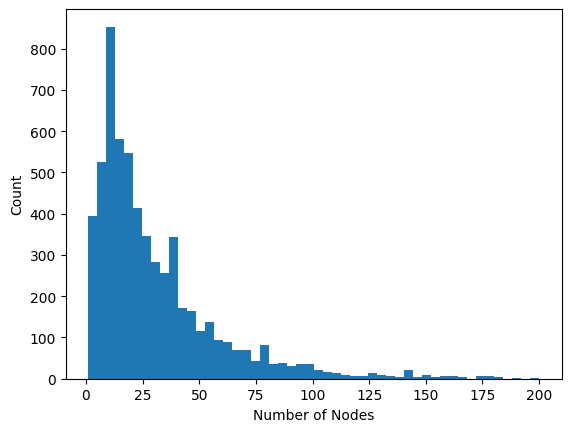

In [61]:
import matplotlib.pyplot as plt

plt.hist(
    [g.num_nodes for g in graph_dataset],
    bins=50
)

plt.xlabel("Number of Nodes")
plt.ylabel("Count")
plt.show()

In [62]:
import torch

for i, g in enumerate(graph_dataset):

    if torch.isnan(g.x).any():
        print("NaN node", i)

    if torch.isnan(g.edge_attr).any():
        print("NaN edge", i)

    if torch.isnan(g.y).any():
        print("NaN target", i)

In [63]:
all_edges = torch.cat(
    [g.edge_attr for g in graph_dataset],
    dim=0
)

edge_mean = all_edges.mean(0)
edge_std = all_edges.std(0)

for g in graph_dataset:

    g.edge_attr = (
        g.edge_attr - edge_mean
    ) / (edge_std + 1e-8)

In [64]:
import pickle

with open(
    "graph_dataset_fe_normalized.pkl",
    "wb"
) as f:

    pickle.dump(
        graph_dataset,
        f
    )

In [67]:
import pickle

with open(
    "graph_dataset_fe_normalized.pkl",
    "rb"
) as f:

    graph_dataset = pickle.load(f)

print("Total Graph:", len(graph_dataset))

Total Graph: 5938


In [68]:
g = graph_dataset[0]

print(g)

Data(x=[6, 19], edge_index=[2, 19], edge_attr=[19, 7], y=[1], material_id='mp-676414')


In [69]:
print("Node Features :", g.x.shape)
print("Edge Features :", g.edge_attr.shape)
print("Target :", g.y)

Node Features : torch.Size([6, 19])
Edge Features : torch.Size([19, 7])
Target : tensor([-0.5870])


In [70]:
import numpy as np

num_nodes = [g.num_nodes for g in graph_dataset]
num_edges = [g.num_edges for g in graph_dataset]

print("Total Graph :", len(graph_dataset))

print("Avg Nodes :", np.mean(num_nodes))
print("Avg Edges :", np.mean(num_edges))

print("Max Nodes :", np.max(num_nodes))
print("Max Edges :", np.max(num_edges))

Total Graph : 5938
Avg Nodes : 30.778039744021555
Avg Edges : 140.81744695183565
Max Nodes : 200
Max Edges : 2008


In [71]:
print(graph_dataset[0].material_id)

mp-676414


# CGCNN FOKUS

In [73]:
import numpy as np
import pandas as pd

targets = np.array([
    g.y.item()
    for g in graph_dataset
])

bins = [
    -5,
    -3,
    -2,
    -1,
    0,
    1,
    2
]

labels = np.digitize(
    targets,
    bins
)

In [75]:
from sklearn.model_selection import train_test_split

indices = np.arange(
    len(graph_dataset)
)

train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.3,
    random_state=42,
    stratify=labels
)

temp_labels = labels[
    temp_idx
]

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,
    random_state=42,
    stratify=temp_labels
)

In [77]:
train_dataset = [
    graph_dataset[i]
    for i in train_idx
]

val_dataset = [
    graph_dataset[i]
    for i in val_idx
]

test_dataset = [
    graph_dataset[i]
    for i in test_idx
]

In [79]:
print("Train :", len(train_dataset))
print("Val   :", len(val_dataset))
print("Test  :", len(test_dataset))

Train : 4156
Val   : 891
Test  : 891


In [81]:
from torch_geometric.loader import DataLoader

In [83]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [85]:
batch = next(
    iter(train_loader)
)

print(batch)

DataBatch(x=[779, 19], edge_index=[2, 3343], edge_attr=[3343, 7], y=[32], material_id=[32], batch=[779], ptr=[33])


In [87]:
import torch
import torch.nn.functional as F

from torch.nn import Linear
from torch.nn import BatchNorm1d
from torch_geometric.nn import (
    CGConv,
    global_mean_pool
)

In [89]:
class FormationEnergyCGCNN(
    torch.nn.Module
):

    def __init__(
        self,
        in_channels=19,
        hidden_channels=128,
        edge_dim=7
    ):

        super().__init__()

        self.embedding = Linear(
            in_channels,
            hidden_channels
        )

        self.conv1 = CGConv(
            hidden_channels,
            dim=edge_dim
        )

        self.bn1 = BatchNorm1d(
            hidden_channels
        )

        self.conv2 = CGConv(
            hidden_channels,
            dim=edge_dim
        )

        self.bn2 = BatchNorm1d(
            hidden_channels
        )

        self.conv3 = CGConv(
            hidden_channels,
            dim=edge_dim
        )

        self.bn3 = BatchNorm1d(
            hidden_channels
        )

        self.fc1 = Linear(
            hidden_channels,
            64
        )

        self.fc2 = Linear(
            64,
            1
        )

    def forward(
        self,
        x,
        edge_index,
        edge_attr,
        batch
    ):

        x = self.embedding(x)

        x = self.conv1(
            x,
            edge_index,
            edge_attr
        )

        x = self.bn1(x)
        x = F.relu(x)

        x = self.conv2(
            x,
            edge_index,
            edge_attr
        )

        x = self.bn2(x)
        x = F.relu(x)

        x = self.conv3(
            x,
            edge_index,
            edge_attr
        )

        x = self.bn3(x)
        x = F.relu(x)

        x = global_mean_pool(
            x,
            batch
        )

        x = F.relu(
            self.fc1(x)
        )

        x = F.dropout(
            x,
            p=0.2,
            training=self.training
        )

        x = self.fc2(x)

        return x.squeeze()

In [90]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

model = FormationEnergyCGCNN().to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=5
)

criterion = torch.nn.SmoothL1Loss()

In [97]:
def train_epoch():

    model.train()

    total_loss = 0

    for batch in train_loader:

        batch = batch.to(device)

        optimizer.zero_grad()

        pred = model(
            batch.x,
            batch.edge_index,
            batch.edge_attr,
            batch.batch
        )

        loss = criterion(
            pred,
            batch.y.view(-1)
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            5.0
        )

        optimizer.step()

        total_loss += (
            loss.item()
            * batch.num_graphs
        )

    return (
        total_loss
        / len(train_loader.dataset)
    )

In [98]:
@torch.no_grad()
def evaluate(loader):

    model.eval()

    total_loss = 0

    predictions = []
    targets = []

    for batch in loader:

        batch = batch.to(device)

        pred = model(
            batch.x,
            batch.edge_index,
            batch.edge_attr,
            batch.batch
        )

        loss = criterion(
            pred,
            batch.y.view(-1)
        )

        total_loss += (
            loss.item()
            * batch.num_graphs
        )

        predictions.extend(
            pred.cpu().numpy()
        )

        targets.extend(
            batch.y.view(-1).cpu().numpy()
        )

    return (
        total_loss / len(loader.dataset),
        np.array(predictions),
        np.array(targets)
    )

In [99]:
best_val_loss = float("inf")

patience = 15
counter = 0

In [100]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

NUM_EPOCHS = 100

train_losses = []
val_losses = []

for epoch in range(NUM_EPOCHS):

    train_loss = train_epoch()

    val_loss, _, _ = evaluate(
        val_loader
    )

    scheduler.step(val_loss)

    train_losses.append(
        train_loss
    )

    val_losses.append(
        val_loss
    )

    print(
        f"Epoch {epoch+1:03d} | "
        f"Train: {train_loss:.4f} | "
        f"Val: {val_loss:.4f}"
    )

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            "best_fe_cgcnn.pth"
        )

        counter = 0

    else:

        counter += 1

    if counter >= patience:

        print(
            "\nEarly stopping!"
        )

        break

Epoch 001 | Train: 0.2809 | Val: 0.1261
Epoch 002 | Train: 0.1378 | Val: 0.1279
Epoch 003 | Train: 0.1217 | Val: 0.0692
Epoch 004 | Train: 0.0958 | Val: 0.0810
Epoch 005 | Train: 0.0955 | Val: 0.0884
Epoch 006 | Train: 0.0866 | Val: 0.0522
Epoch 007 | Train: 0.0826 | Val: 0.0910
Epoch 008 | Train: 0.0760 | Val: 0.0464
Epoch 009 | Train: 0.0704 | Val: 0.0471
Epoch 010 | Train: 0.0653 | Val: 0.0422
Epoch 011 | Train: 0.0607 | Val: 0.0474
Epoch 012 | Train: 0.0653 | Val: 0.0682
Epoch 013 | Train: 0.0568 | Val: 0.0502
Epoch 014 | Train: 0.0538 | Val: 0.0457
Epoch 015 | Train: 0.0548 | Val: 0.0427
Epoch 016 | Train: 0.0521 | Val: 0.0383
Epoch 017 | Train: 0.0526 | Val: 0.0434
Epoch 018 | Train: 0.0531 | Val: 0.0361
Epoch 019 | Train: 0.0493 | Val: 0.0464
Epoch 020 | Train: 0.0492 | Val: 0.0554
Epoch 021 | Train: 0.0436 | Val: 0.0443
Epoch 022 | Train: 0.0440 | Val: 0.0356
Epoch 023 | Train: 0.0417 | Val: 0.0322
Epoch 024 | Train: 0.0416 | Val: 0.0399
Epoch 025 | Train: 0.0423 | Val: 0.0327


In [101]:
model.load_state_dict(
    torch.load(
        "best_fe_cgcnn.pth"
    )
)

<All keys matched successfully>

In [102]:
test_loss, pred, true = evaluate(
    test_loader
)

print(
    "Test Loss:",
    test_loss
)

Test Loss: 0.02116500983363818


In [103]:
mae = mean_absolute_error(
    true,
    pred
)

rmse = np.sqrt(
    mean_squared_error(
        true,
        pred
    )
)

r2 = r2_score(
    true,
    pred
)

print(
    f"MAE  : {mae:.4f}"
)

print(
    f"RMSE : {rmse:.4f}"
)

print(
    f"R²   : {r2:.4f}"
)

MAE  : 0.1265
RMSE : 0.2208
R²   : 0.9622


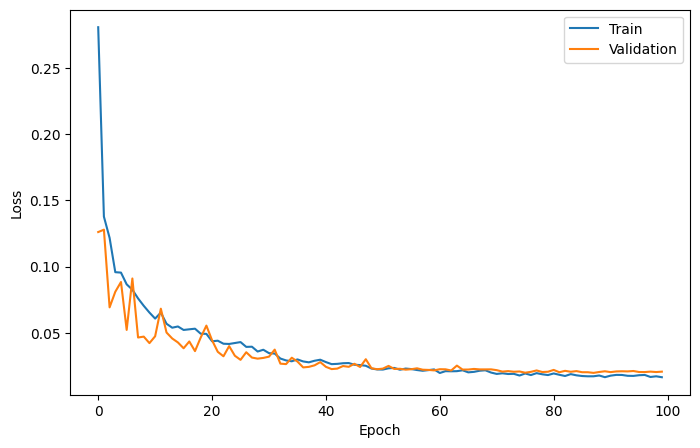

In [104]:
import matplotlib.pyplot as plt

plt.figure(
    figsize=(8,5)
)

plt.plot(
    train_losses,
    label="Train"
)

plt.plot(
    val_losses,
    label="Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

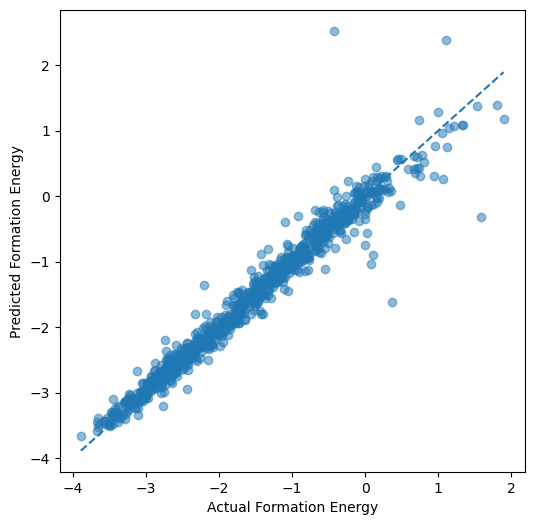

In [105]:
plt.figure(
    figsize=(6,6)
)

plt.scatter(
    true,
    pred,
    alpha=0.5
)

plt.plot(
    [true.min(), true.max()],
    [true.min(), true.max()],
    "--"
)

plt.xlabel(
    "Actual Formation Energy"
)

plt.ylabel(
    "Predicted Formation Energy"
)

plt.show()

In [106]:
errors = np.abs(
    pred - true
)

print(
    "Mean Error:",
    errors.mean()
)

print(
    "Median Error:",
    np.median(errors)
)

print(
    "Error < 0.05 eV:",
    (errors < 0.05).mean()*100
)

print(
    "Error < 0.10 eV:",
    (errors < 0.10).mean()*100
)

print(
    "Error < 0.20 eV:",
    (errors < 0.20).mean()*100
)

Mean Error: 0.12652586
Median Error: 0.087587
Error < 0.05 eV: 31.200897867564535
Error < 0.10 eV: 56.11672278338945
Error < 0.20 eV: 83.16498316498317


In [ ]:
import pandas as pd
import numpy as np

results = pd.DataFrame({

    "Actual": true,
    "Predicted": pred,
    "Error": pred - true,
    "Absolute_Error": np.abs(pred - true)

})

print(results.head(20))

      Actual  Predicted     Error  Absolute_Error
0  -2.972158  -2.993168 -0.021010        0.021010
1  -1.324155  -1.512963 -0.188807        0.188807
2  -2.193267  -2.183026  0.010241        0.010241
3  -0.968804  -1.018006 -0.049203        0.049203
4  -2.476185  -2.530010 -0.053825        0.053825
5  -2.001678  -2.074498 -0.072820        0.072820
6  -1.298690  -1.322767 -0.024077        0.024077
7  -1.522453  -1.309778  0.212675        0.212675
8  -2.796489  -2.732428  0.064060        0.064060
9   0.802551   0.522259 -0.280291        0.280291
10 -1.278934  -1.317638 -0.038704        0.038704
11  0.730337   0.426398 -0.303939        0.303939
12 -1.863140  -1.985206 -0.122066        0.122066
13  0.771255   0.622609 -0.148646        0.148646
14 -0.128615  -0.218600 -0.089985        0.089985
15 -3.225765  -3.155286  0.070479        0.070479
16 -0.710917  -0.446342  0.264575        0.264575
17 -2.487940  -2.576630 -0.088691        0.088691
18 -0.680796  -0.739894 -0.059098        0.059098


# BAND GAP

In [77]:
from mp_api.client import MPRester
import pandas as pd
import random


N_PER_BIN = 600

all_materials = []

bins = [
    ("metal", (0.0, 0.0)),
    ("semi_metal", (0.001, 0.5)),
    ("bg_0_5_1", (0.5, 1.0)),
    ("bg_1_2", (1.0, 2.0)),
    ("bg_2_3", (2.0, 3.0))
]

with MPRester(API_KEY) as mpr:

    for name, bg_range in bins:

        print(f"Mengambil {name} ...")

        docs = list(
            mpr.materials.summary.search(
                band_gap=bg_range,
                fields=[
                    "material_id",
                    "formula_pretty",
                    "band_gap",
                    "formation_energy_per_atom",
                    "structure",
                    "is_metal",
                    "nsites",
                    "density",
                    "volume"
                ]
            )
        )

        print(f"Ditemukan {len(docs)} material")

        if len(docs) >= N_PER_BIN:
            docs = random.sample(docs, N_PER_BIN)

        all_materials.extend(docs)

print(f"\nTotal material = {len(all_materials)}")

Mengambil metal ...


Retrieving SummaryDoc documents:   0%|          | 0/72456 [00:00<?, ?it/s]

Ditemukan 72456 material
Mengambil semi_metal ...


Retrieving SummaryDoc documents:   0%|          | 0/15836 [00:00<?, ?it/s]

Ditemukan 15836 material
Mengambil bg_0_5_1 ...


...

Ditemukan 10950 material
Mengambil bg_1_2 ...


Retrieving SummaryDoc documents:   0%|          | 0/18605 [00:00<?, ?it/s]

Ditemukan 18605 material
Mengambil bg_2_3 ...


Retrieving SummaryDoc documents:   0%|          | 0/15656 [00:00<?, ?it/s]

Ditemukan 15656 material

Total material = 3000


In [78]:
records = []

for m in all_materials:

    records.append({
        "material_id": str(m.material_id),
        "formula": m.formula_pretty,
        "band_gap": m.band_gap,
        "formation_energy": m.formation_energy_per_atom,
        "is_metal": m.is_metal,
        "nsites": m.nsites,
        "density": m.density,
        "volume": m.volume,
        "structure": m.structure
    })

df_bg = pd.DataFrame(records)

print(df_bg.shape)
df_bg.head()

(3000, 9)


,material_id,formula,band_gap,formation_energy,is_metal,nsites,density,volume,structure
0,mp-641683,Eu2Ir2O7,0.0,-2.213916,True,22,9.628354,276.064932,"[[6.45886575 6.45868848 6.45941673] Eu, [6.459..."
1,mp-1022005,NaMg6Ni,0.0,0.136939,True,16,2.249853,335.839296,"[[2.477703 3.1463075 1.80461134] Na, [2.477..."
2,mp-1035724,KHfMg14O15,0.0,-2.710100,True,31,3.941083,336.166431,"[[0.15251734 0. 0. ] K, [4.3309..."
3,mp-1183385,Ba3Dy,0.0,0.228939,True,8,4.630301,412.045843,"[[2.17685845 1.25680983 1.6797075 ] Ba, [6.238..."
4,mp-1212483,Hg4PHNO7,0.0,-0.990648,True,56,6.470591,985.807398,"[[-4.26481684 -3.81875345 5.95922445] Hg, [ 4..."


DATASET SHAPE
(5938, 8)

BAND GAP BIN DISTRIBUTION
bg_bin
(-0.001, 0.0]    1980
(0.0, 0.5]       1967
(0.5, 1.0]        422
(1.0, 2.0]        818
(2.0, 3.0]        751
Name: count, dtype: int64

BAND GAP STATISTICS
count    5938.000000
mean        0.642148
std         0.870810
min         0.000000
25%         0.000000
50%         0.194364
75%         1.110575
max         2.998700
Name: band_gap, dtype: float64

NSITES STATISTICS
count    5938.00000
mean       30.77804
std        28.49284
min         1.00000
25%        11.00000
50%        22.00000
75%        40.00000
max       200.00000
Name: nsites, dtype: float64

FORMATION ENERGY STATISTICS
count    5938.000000
mean       -1.548855
std         1.135122
min        -4.287387
25%        -2.460488
50%        -1.688203
75%        -0.605758
max         1.944946
Name: formation_energy, dtype: float64


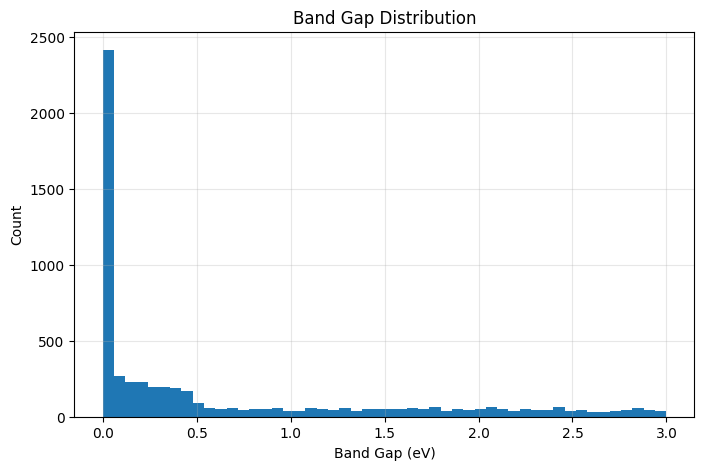

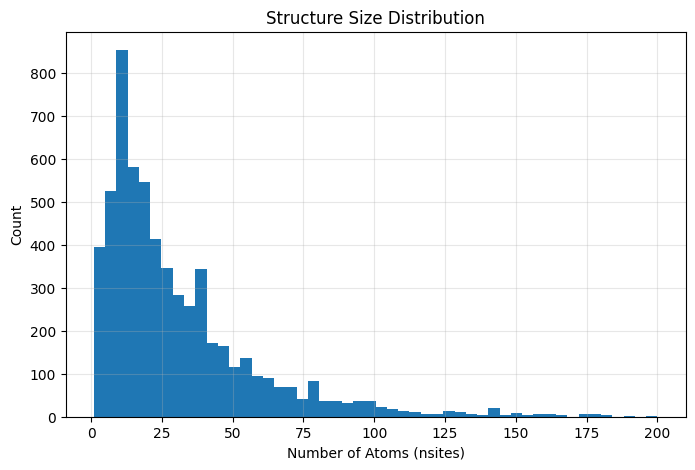


STRUCTURES WITH nsites > 200
0

Largest Structures:
     material_id              formula  band_gap  nsites
5574   mp-645316                 C7F3    1.4238     200
3209   mp-699488       CsTiH24(SO10)2    0.1522     192
2622   mp-746676       CsMnH24(SO10)2    0.0156     192
5092   mp-680711            Ca4Te5O14    2.9384     184
3754   mp-653781             BaNb8O14    0.3029     184
5364  mp-1205468             BaNb8O14    0.5377     184
5918   mp-699932  Ba3Li2Mo4P6(ClO14)2    2.1138     180
5228  mp-1197599         Ag2Sn(S2O7)3    2.4602     180
4767  mp-1238166          CaB12(H3O)8    1.1297     180
821    mp-729893           Ba9Ge23O57    0.0000     178


In [79]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================
# Band Gap Bin Distribution
# ==========================
df["bg_bin"] = pd.cut(
    df["band_gap"],
    bins=[-0.001, 0.0, 0.5, 1.0, 2.0, 3.0]
)

print("=" * 60)
print("DATASET SHAPE")
print("=" * 60)
print(df.shape)

print("\n" + "=" * 60)
print("BAND GAP BIN DISTRIBUTION")
print("=" * 60)
print(df["bg_bin"].value_counts().sort_index())

print("\n" + "=" * 60)
print("BAND GAP STATISTICS")
print("=" * 60)
print(df["band_gap"].describe())

print("\n" + "=" * 60)
print("NSITES STATISTICS")
print("=" * 60)
print(df["nsites"].describe())

print("\n" + "=" * 60)
print("FORMATION ENERGY STATISTICS")
print("=" * 60)
print(df["formation_energy"].describe())

# ==========================
# Histogram Band Gap
# ==========================
plt.figure(figsize=(8,5))
plt.hist(df["band_gap"], bins=50)
plt.xlabel("Band Gap (eV)")
plt.ylabel("Count")
plt.title("Band Gap Distribution")
plt.grid(alpha=0.3)
plt.show()

# ==========================
# Histogram Nsites
# ==========================
plt.figure(figsize=(8,5))
plt.hist(df["nsites"], bins=50)
plt.xlabel("Number of Atoms (nsites)")
plt.ylabel("Count")
plt.title("Structure Size Distribution")
plt.grid(alpha=0.3)
plt.show()

# ==========================
# Outlier Check
# ==========================
print("\n" + "=" * 60)
print("STRUCTURES WITH nsites > 200")
print("=" * 60)

print((df["nsites"] > 200).sum())

print("\nLargest Structures:")
print(
    df.sort_values("nsites", ascending=False)[
        ["material_id", "formula", "band_gap", "nsites"]
    ].head(10)
)

Distribusi Awal
bg_bin
(-0.002, 0.0]    1980
(0.0, 0.5]       1967
(0.5, 1.0]        422
(1.0, 2.0]        818
(2.0, 3.0]        751
Name: count, dtype: int64

Distribusi Setelah Balancing
bg_bin
(-0.002, 0.0]    600
(0.0, 0.5]       600
(0.5, 1.0]       422
(1.0, 2.0]       600
(2.0, 3.0]       600
Name: count, dtype: int64

Ukuran Dataset Baru
(2822, 8)

Band Gap Statistics
count    2822.000000
mean        1.001039
std         0.957059
min         0.000000
25%         0.041250
50%         0.732400
75%         1.797200
max         2.994600
Name: band_gap, dtype: float64

Nsites Statistics
count    2822.000000
mean       31.864635
std        29.218767
min         1.000000
25%        11.000000
50%        22.500000
75%        40.000000
max       200.000000
Name: nsites, dtype: float64


C:\Users\USER\AppData\Local\Temp\ipykernel_16120\913543421.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("bg_bin", group_keys=False)
C:\Users\USER\AppData\Local\Temp\ipykernel_16120\913543421.py:31: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


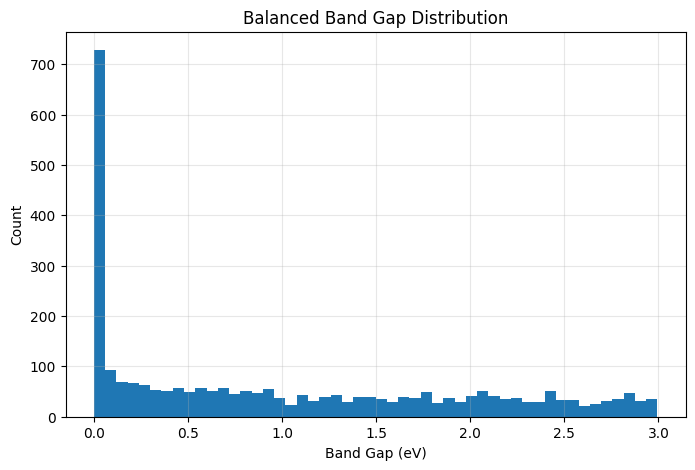

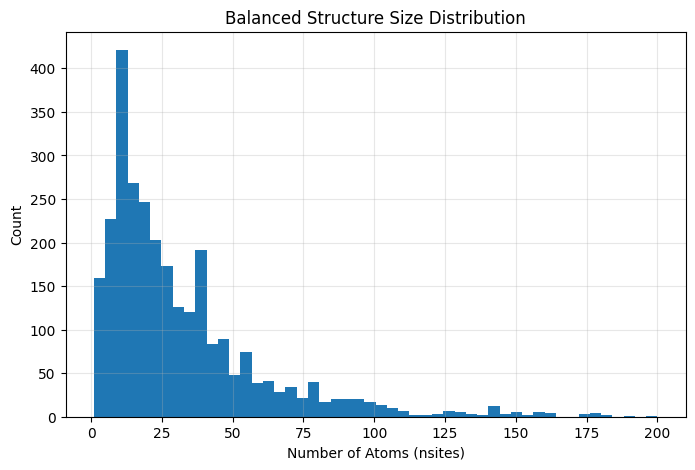


Dataset disimpan:
bandgap_3000_balanced.pkl


In [81]:
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================
# 1. Buat Bin Band Gap
# =====================================================

bins = [-0.001, 0.0, 0.5, 1.0, 2.0, 3.0]

df["bg_bin"] = pd.cut(
    df["band_gap"],
    bins=bins,
    include_lowest=True
)

# =====================================================
# 2. Cek Jumlah Data per Bin
# =====================================================

print("Distribusi Awal")
print(df["bg_bin"].value_counts().sort_index())

# =====================================================
# 3. Ambil 600 Material per Bin
# =====================================================

N_PER_BIN = 600

balanced_df = (
    df.groupby("bg_bin", group_keys=False)
      .apply(
          lambda x: x.sample(
              n=min(len(x), N_PER_BIN),
              random_state=42
          )
      )
      .reset_index(drop=True)
)

# =====================================================
# 4. Cek Distribusi Baru
# =====================================================

print("\nDistribusi Setelah Balancing")
print(
    balanced_df["bg_bin"]
    .value_counts()
    .sort_index()
)

print("\nUkuran Dataset Baru")
print(balanced_df.shape)

# =====================================================
# 5. Statistik
# =====================================================

print("\nBand Gap Statistics")
print(balanced_df["band_gap"].describe())

print("\nNsites Statistics")
print(balanced_df["nsites"].describe())

# =====================================================
# 6. Histogram Band Gap
# =====================================================

plt.figure(figsize=(8,5))

plt.hist(
    balanced_df["band_gap"],
    bins=50
)

plt.xlabel("Band Gap (eV)")
plt.ylabel("Count")
plt.title("Balanced Band Gap Distribution")
plt.grid(alpha=0.3)

plt.show()

# =====================================================
# 7. Histogram Nsites
# =====================================================

plt.figure(figsize=(8,5))

plt.hist(
    balanced_df["nsites"],
    bins=50
)

plt.xlabel("Number of Atoms (nsites)")
plt.ylabel("Count")
plt.title("Balanced Structure Size Distribution")
plt.grid(alpha=0.3)

plt.show()

# =====================================================
# 8. Simpan Dataset
# =====================================================

balanced_df.to_pickle("bandgap_3000_balanced.pkl")

print("\nDataset disimpan:")
print("bandgap_3000_balanced.pkl")

In [82]:
print(balanced_df.shape)

print(
    balanced_df["bg_bin"]
    .value_counts()
    .sort_index()
)

(2822, 8)
bg_bin
(-0.002, 0.0]    600
(0.0, 0.5]       600
(0.5, 1.0]       422
(1.0, 2.0]       600
(2.0, 3.0]       600
Name: count, dtype: int64


In [86]:
import os 

# Buat Folder
os.makedirs("Dataset Bandgap", exist_ok=True)

# Simpan Filde
balanced_df.to_pickle(
    "Dataset Bandgap/bandgap_dataset_.pkl"
)

print("Berhasil Bray:", len(balanced_df))

Berhasil Bray: 2822


In [88]:
# load Dataset

import pandas as pd 

df_bg = pd.read_pickle("bandgap_dataset.pkl")
df_bg.head()

,material_id,formula,band_gap,formation_energy,is_metal,nsites,structure
0,mp-676414,Al4CO,0.0,-0.587042,True,6,[[3.57781860e-03 3.94083151e+00 3.11930310e+00...
1,mp-865953,AcYbZn2,0.0,-0.242078,True,4,"[[3.71742369 3.71742369 3.71742369] Ac, [0. 0...."
2,mp-1026819,BaLiMg14,0.0,0.097091,True,16,[[3.33651295e-06 1.92633450e+00 6.53714443e+00...
3,mp-1104205,BaErFe4O7,0.0,-2.193267,True,13,[[3.16664800e+00 2.22044605e-16 2.32347650e+00...
4,mp-1229149,Ba10Er5Cu15O34,0.0,-2.204054,True,64,"[[3.2738032 6.09321347 9.6073013 ] Ba, [-0.09..."


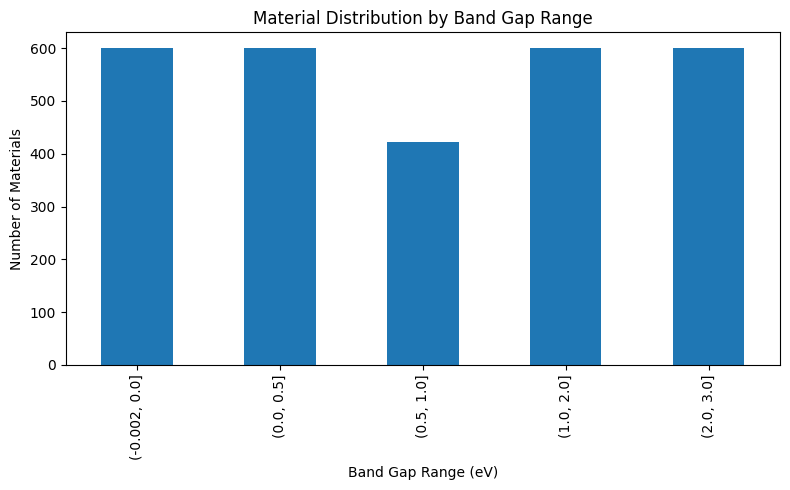

In [89]:
plt.figure(figsize=(8,5))

balanced_df["bg_bin"].value_counts()\
    .sort_index()\
    .plot(kind="bar")

plt.xlabel("Band Gap Range (eV)")
plt.ylabel("Number of Materials")
plt.title("Material Distribution by Band Gap Range")

plt.tight_layout()
plt.show()

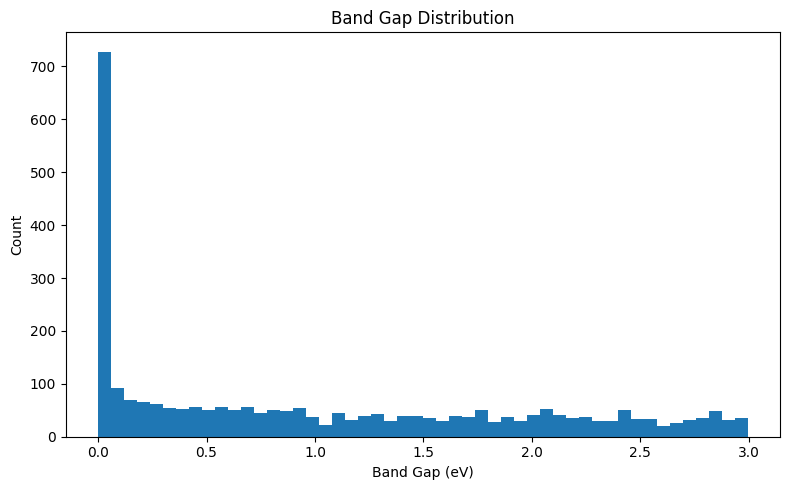

In [90]:
plt.figure(figsize=(8,5))

plt.hist(
    balanced_df["band_gap"],
    bins=50
)

plt.xlabel("Band Gap (eV)")
plt.ylabel("Count")
plt.title("Band Gap Distribution")

plt.tight_layout()
plt.show()

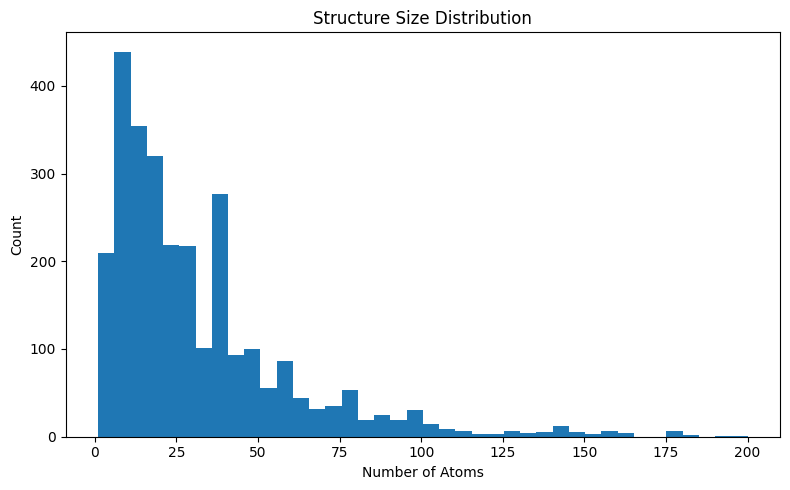

In [91]:
plt.figure(figsize=(8,5))

plt.hist(
    balanced_df["nsites"],
    bins=40
)

plt.xlabel("Number of Atoms")
plt.ylabel("Count")
plt.title("Structure Size Distribution")

plt.tight_layout()
plt.show()

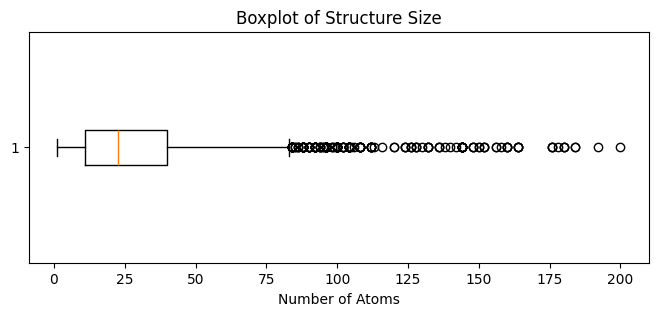

In [92]:
plt.figure(figsize=(8,3))

plt.boxplot(
    balanced_df["nsites"],
    vert=False
)

plt.xlabel("Number of Atoms")
plt.title("Boxplot of Structure Size")

plt.show()

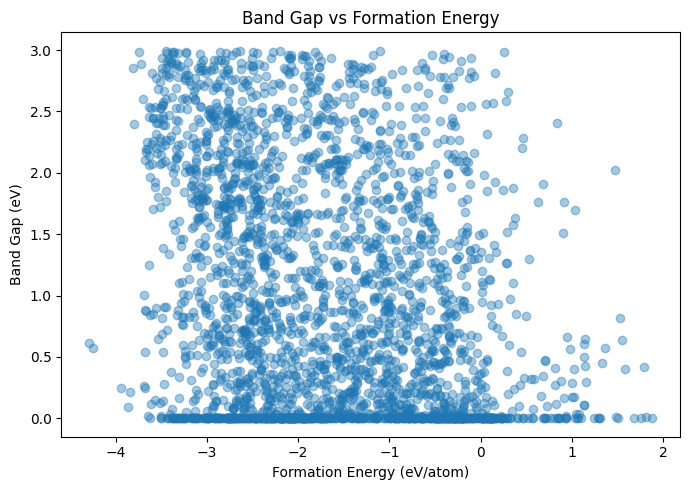

In [93]:
plt.figure(figsize=(7,5))

plt.scatter(
    balanced_df["formation_energy"],
    balanced_df["band_gap"],
    alpha=0.4
)

plt.xlabel("Formation Energy (eV/atom)")
plt.ylabel("Band Gap (eV)")
plt.title("Band Gap vs Formation Energy")

plt.tight_layout()
plt.show()

In [94]:
summary = balanced_df[
    ["band_gap",
     "formation_energy",
     "nsites"]
].describe()

print(summary)

          band_gap  formation_energy       nsites
count  2822.000000       2822.000000  2822.000000
mean      1.001039         -1.667883    31.864635
std       0.957059          1.128516    29.218767
min       0.000000         -4.287387     1.000000
25%       0.041250         -2.586591    11.000000
50%       0.732400         -1.777152    22.500000
75%       1.797200         -0.765542    40.000000
max       2.994600          1.877627   200.000000


In [107]:
import pandas as pd

df = pd.read_pickle(
    "Dataset Bandgap/bandgap_dataset_.pkl"
)

print("Shape :", df.shape)

df.head()

Shape : (2822, 8)


,material_id,formula,band_gap,formation_energy,is_metal,nsites,structure,bg_bin
0,mp-2758269,Al(VS2)4,0.0,-1.173899,True,13,"[[-0.00548128 0.00917065 0.00963159] Al, [3....","(-0.002, 0.0]"
1,mp-1016566,BaMg6Bi,0.0,0.014726,True,16,"[[0. 3.6133785 4.03759621] Ba, [ 0. ...","(-0.002, 0.0]"
2,mp-22733,Ba2Ni(NO2)6,0.0,0.461236,True,21,"[[2.588641 2.588641 2.588641] Ba, [7.765923 7....","(-0.002, 0.0]"
3,mp-2232700,Ba3MgNb2ZnO9,0.0,-2.691790,True,16,"[[2.94131432 1.15271368 2.79870286] Ba, [-3.26...","(-0.002, 0.0]"
4,mp-1183208,AlGa3,0.0,0.124631,True,4,"[[0. 0. 0.] Al, [0. 2.01804512 2.09556...","(-0.002, 0.0]"


In [109]:
print(df.columns)

Index(['material_id', 'formula', 'band_gap', 'formation_energy', 'is_metal',
       'nsites', 'structure', 'bg_bin'],
      dtype='object')


In [110]:
import torch
import pickle

from tqdm import tqdm

from pymatgen.analysis.local_env import CrystalNN
from pymatgen.core.periodic_table import Element

from torch_geometric.data import Data

In [111]:
cnn = CrystalNN()

In [112]:
def atom_features(site):

    elem = Element(site.specie.symbol)

    atomic_radius = elem.atomic_radius or 0
    ionic_radius = elem.average_ionic_radius or 0
    calc_radius = elem.atomic_radius_calculated or 0

    en = elem.X or 0

    try:
        max_ox = max(elem.common_oxidation_states)
    except:
        max_ox = 0

    try:
        min_ox = min(elem.common_oxidation_states)
    except:
        min_ox = 0

    try:
        valence = elem.nvalence()
    except:
        valence = 0

    try:
        outer_e = elem.full_electronic_structure[-1][2]
    except:
        outer_e = 0

    return [

        elem.Z / 100,
        float(elem.atomic_mass) / 300,

        en / 4,

        elem.group / 18,
        elem.row / 7,

        atomic_radius / 3,
        ionic_radius / 2,
        calc_radius / 3,

        (elem.mendeleev_no or 0) / 120,

        valence / 12,
        outer_e / 14,

        max_ox / 8,
        min_ox / 8,

        1 if elem.block == "s" else 0,
        1 if elem.block == "p" else 0,
        1 if elem.block == "d" else 0,
        1 if elem.block == "f" else 0,

        1 if elem.is_metal else 0,

        1 if elem.is_transition_metal else 0
    ]

In [113]:
def structure_to_graph(structure, band_gap):

    x = torch.tensor(
        [atom_features(site) for site in structure],
        dtype=torch.float
    )

    edge_index = []
    edge_attr = []

    for i in range(len(structure)):

        try:

            neighbors = cnn.get_nn_info(
                structure,
                i
            )

            coord_num = len(neighbors)

            elem_i = Element(
                structure[i].specie.symbol
            )

            chi_i = elem_i.X or 0
            rad_i = elem_i.atomic_radius or 0

            for nn in neighbors:

                j = nn["site_index"]

                elem_j = Element(
                    structure[j].specie.symbol
                )

                chi_j = elem_j.X or 0
                rad_j = elem_j.atomic_radius or 0

                distance = structure.get_distance(
                    i,
                    j
                )

                edge_index.append([i, j])

                edge_attr.append([

                    distance,

                    nn["weight"],

                    abs(chi_i - chi_j),

                    abs(rad_i - rad_j),

                    (chi_i + chi_j) / 2,

                    (rad_i + rad_j) / 2,

                    coord_num
                ])

        except:
            continue

    if len(edge_index) == 0:
        return None

    edge_index = torch.tensor(
        edge_index,
        dtype=torch.long
    ).t().contiguous()

    edge_attr = torch.tensor(
        edge_attr,
        dtype=torch.float
    )

    y = torch.tensor(
        [band_gap],
        dtype=torch.float
    )

    return Data(
        x=x,
        edge_index=edge_index,
        edge_attr=edge_attr,
        y=y
    )

In [114]:
graph_dataset = []

for _, row in tqdm(
    df.iterrows(),
    total=len(df)
):

    graph = structure_to_graph(
        row["structure"],
        row["band_gap"]
    )

    if graph is not None:

        graph_dataset.append(
            graph
        )

print()

print(
    "Total Graph :",
    len(graph_dataset)
)

  0%|          | 0/2822 [00:00<?, ?it/s]c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\pymatgen\core\local_env.py:4029: UserWarning: No oxidation states specified on sites! For better results, set the site oxidation states in the structure.
  r1 = _get_radius(structure[n])
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\pymatgen\core\local_env.py:4031: UserWarning: No oxidation states specified on sites! For better results, set the site oxidation states in the structure.
  r2 = _get_radius(entry["site"])
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\pymatgen\core\local_env.py:3943: UserWarning: CrystalNN: cannot locate an appropriate radius, covalent or atomic radii will be used, this can lead to non-optimal results.
  nn_data = self.get_nn_data(structure, n)
  1%|          | 16/2822 [00:05<14:11,  3.30it/s]C:\Users\USER\AppData\Local\Temp\ipykernel_16120\3752345933.py:7: UserWarning: No data available for atomi


Total Graph : 2821


In [115]:
print(graph_dataset[0])

Data(x=[13, 19], edge_index=[2, 56], edge_attr=[56, 7], y=[1])


In [116]:
num_nodes = []
num_edges = []

for g in graph_dataset:

    num_nodes.append(g.num_nodes)
    num_edges.append(g.num_edges)

print()

print("Total Graph :", len(graph_dataset))

print(
    f"Avg Nodes : {sum(num_nodes)/len(num_nodes):.2f}"
)

print(
    f"Avg Edges : {sum(num_edges)/len(num_edges):.2f}"
)

print(
    f"Max Nodes : {max(num_nodes)}"
)

print(
    f"Max Edges : {max(num_edges)}"
)


Total Graph : 2821
Avg Nodes : 31.88
Avg Edges : 131.48
Max Nodes : 200
Max Edges : 1800


In [117]:
import os
import pickle


with open(
    "Dataset Bandgap/bandgap_graph_dataset.pkl",
    "wb"
) as f:

    pickle.dump(
        graph_dataset,
        f
    )

print(
    "Graph dataset saved."
)

Graph dataset saved.


In [118]:
print(graph_dataset[0])

print("Total Graph :", len(graph_dataset))
print(f"Avg Nodes : {sum(num_nodes)/len(num_nodes):.2f}")
print(f"Avg Edges : {sum(num_edges)/len(num_edges):.2f}")
print(f"Max Nodes : {max(num_nodes)}")
print(f"Max Edges : {max(num_edges)}")

Data(x=[13, 19], edge_index=[2, 56], edge_attr=[56, 7], y=[1])
Total Graph : 2821
Avg Nodes : 31.88
Avg Edges : 131.48
Max Nodes : 200
Max Edges : 1800


# CGCNN FOCUS

In [123]:
print(len(df))
print(len(graph_dataset))

2822
2821


In [125]:
bins = [-0.001, 0.0, 0.5, 1.0, 2.0, 3.0]

df["bg_bin"] = pd.cut(
    df["band_gap"],
    bins=bins,
    labels=False
)

In [127]:
from sklearn.model_selection import train_test_split

indices = list(range(len(graph_dataset)))

train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.2,
    stratify=df["bg_bin"],
    random_state=42
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,
    stratify=df.iloc[temp_idx]["bg_bin"],
    random_state=42
)

In [128]:
train_dataset = [
    graph_dataset[i]
    for i in train_idx
]

val_dataset = [
    graph_dataset[i]
    for i in val_idx
]

test_dataset = [
    graph_dataset[i]
    for i in test_idx
]

In [129]:
print("Train :", len(train_dataset))
print("Val   :", len(val_dataset))
print("Test  :", len(test_dataset))

Train : 2256
Val   : 282
Test  : 283


In [130]:
from collections import Counter

print("Train")
print(
    Counter(
        df.iloc[train_idx]["bg_bin"]
    )
)

print()

print("Validation")
print(
    Counter(
        df.iloc[val_idx]["bg_bin"]
    )
)

print()

print("Test")
print(
    Counter(
        df.iloc[test_idx]["bg_bin"]
    )
)

Train
Counter({0: 480, 3: 480, 1: 480, 4: 479, 2: 337})

Validation
Counter({4: 60, 1: 60, 3: 60, 0: 60, 2: 42})

Test
Counter({4: 60, 1: 60, 0: 60, 3: 60, 2: 43})


In [131]:
from torch_geometric.loader import DataLoader

BATCH_SIZE = 32

In [132]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [133]:
batch = next(
    iter(train_loader)
)

print(batch)

DataBatch(x=[1063, 19], edge_index=[2, 4170], edge_attr=[4170, 7], y=[32], batch=[1063], ptr=[33])


In [134]:
import pickle

with open("Dataset Bandgap/train_dataset.pkl", "wb") as f:
    pickle.dump(train_dataset, f)

with open("Dataset Bandgap/val_dataset.pkl", "wb") as f:
    pickle.dump(val_dataset, f)

with open("Dataset Bandgap/test_dataset.pkl", "wb") as f:
    pickle.dump(test_dataset, f)

In [135]:
print("Train :", len(train_dataset))
print("Val   :", len(val_dataset))
print("Test  :", len(test_dataset))

batch = next(iter(train_loader))
print(batch)

Train : 2256
Val   : 282
Test  : 283
DataBatch(x=[932, 19], edge_index=[2, 3666], edge_attr=[3666, 7], y=[32], batch=[932], ptr=[33])


In [136]:
import torch
import torch.nn.functional as F

from torch.nn import Linear
from torch.nn import BatchNorm1d

from torch_geometric.nn import (
    CGConv,
    global_mean_pool
)

In [137]:
class BandGapCGNN(torch.nn.Module):

    def __init__(
        self,
        in_channels=19,
        hidden_channels=128,
        edge_dim=7
    ):

        super().__init__()

        self.embedding = Linear(
            in_channels,
            hidden_channels
        )

        self.conv1 = CGConv(
            hidden_channels,
            dim=edge_dim
        )

        self.bn1 = BatchNorm1d(
            hidden_channels
        )

        self.conv2 = CGConv(
            hidden_channels,
            dim=edge_dim
        )

        self.bn2 = BatchNorm1d(
            hidden_channels
        )

        self.conv3 = CGConv(
            hidden_channels,
            dim=edge_dim
        )

        self.bn3 = BatchNorm1d(
            hidden_channels
        )

        self.fc1 = Linear(
            hidden_channels,
            64
        )

        self.fc2 = Linear(
            64,
            32
        )

        self.fc3 = Linear(
            32,
            1
        )

        self.dropout = torch.nn.Dropout(
            0.2
        )

    def forward(
        self,
        x,
        edge_index,
        edge_attr,
        batch
    ):

        x = self.embedding(x)

        x = self.conv1(
            x,
            edge_index,
            edge_attr
        )

        x = self.bn1(x)

        x = F.relu(x)

        x = self.conv2(
            x,
            edge_index,
            edge_attr
        )

        x = self.bn2(x)

        x = F.relu(x)

        x = self.conv3(
            x,
            edge_index,
            edge_attr
        )

        x = self.bn3(x)

        x = F.relu(x)

        x = global_mean_pool(
            x,
            batch
        )

        x = self.fc1(x)

        x = F.relu(x)

        x = self.dropout(x)

        x = self.fc2(x)

        x = F.relu(x)

        x = self.dropout(x)

        x = self.fc3(x)

        return x.squeeze()

In [138]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(device)

cpu


In [139]:
model = BandGapCGNN().to(device)

print(model)

BandGapCGNN(
  (embedding): Linear(in_features=19, out_features=128, bias=True)
  (conv1): CGConv(128, dim=7)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): CGConv(128, dim=7)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): CGConv(128, dim=7)
  (bn3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=128, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=1, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)


In [140]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)

In [141]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

scheduler = ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=5
)

In [142]:
criterion = torch.nn.SmoothL1Loss()

In [143]:
batch = next(iter(train_loader))

batch = batch.to(device)

out = model(
    batch.x,
    batch.edge_index,
    batch.edge_attr,
    batch.batch
)

print(out.shape)

torch.Size([32])


In [144]:
def train_epoch(model, loader, optimizer, criterion, device):

    model.train()

    total_loss = 0

    for batch in loader:

        batch = batch.to(device)

        optimizer.zero_grad()

        pred = model(
            batch.x,
            batch.edge_index,
            batch.edge_attr,
            batch.batch
        )

        loss = criterion(
            pred,
            batch.y.view(-1)
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [145]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):

    model.eval()

    total_loss = 0

    preds = []
    targets = []

    for batch in loader:

        batch = batch.to(device)

        pred = model(
            batch.x,
            batch.edge_index,
            batch.edge_attr,
            batch.batch
        )

        loss = criterion(
            pred,
            batch.y.view(-1)
        )

        total_loss += loss.item()

        preds.extend(
            pred.cpu().numpy()
        )

        targets.extend(
            batch.y.view(-1).cpu().numpy()
        )

    return (
        total_loss / len(loader),
        preds,
        targets
    )

In [146]:
best_val_loss = float("inf")

patience = 15

counter = 0

In [147]:
EPOCHS = 100

In [149]:
train_losses = []
val_losses = []

for epoch in range(EPOCHS):

    train_loss = train_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        device
    )

    val_loss, _, _ = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch {epoch+1:03d} | "
        f"Train: {train_loss:.4f} | "
        f"Val: {val_loss:.4f}"
    )

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        counter = 0

        torch.save(
            model.state_dict(),
            "Dataset Bandgap/best_bandgap_model.pth"
        )

    else:

        counter += 1

    if counter >= patience:

        print(
            "\nEarly stopping triggered."
        )

        break

Epoch 001 | Train: 0.3690 | Val: 0.3400
Epoch 002 | Train: 0.3533 | Val: 0.3443
Epoch 003 | Train: 0.3439 | Val: 0.3164
Epoch 004 | Train: 0.3250 | Val: 0.3440
Epoch 005 | Train: 0.3281 | Val: 0.3022
Epoch 006 | Train: 0.3090 | Val: 0.3576
Epoch 007 | Train: 0.3103 | Val: 0.3100
Epoch 008 | Train: 0.2979 | Val: 0.3305
Epoch 009 | Train: 0.2958 | Val: 0.2922
Epoch 010 | Train: 0.2883 | Val: 0.3164
Epoch 011 | Train: 0.2802 | Val: 0.3106
Epoch 012 | Train: 0.2821 | Val: 0.3406
Epoch 013 | Train: 0.2783 | Val: 0.3304
Epoch 014 | Train: 0.2681 | Val: 0.3606
Epoch 015 | Train: 0.2584 | Val: 0.2733
Epoch 016 | Train: 0.2481 | Val: 0.2884
Epoch 017 | Train: 0.2492 | Val: 0.3060
Epoch 018 | Train: 0.2432 | Val: 0.2958
Epoch 019 | Train: 0.2389 | Val: 0.2715
Epoch 020 | Train: 0.2372 | Val: 0.2834
Epoch 021 | Train: 0.2352 | Val: 0.2792
Epoch 022 | Train: 0.2309 | Val: 0.3136
Epoch 023 | Train: 0.2289 | Val: 0.2900
Epoch 024 | Train: 0.2214 | Val: 0.2759
Epoch 025 | Train: 0.2230 | Val: 0.2691


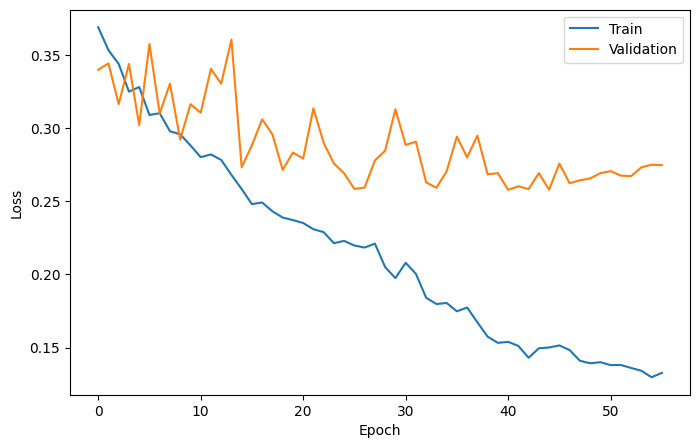

In [150]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    train_losses,
    label="Train"
)

plt.plot(
    val_losses,
    label="Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

In [152]:
test_loss, preds, targets = evaluate(
    model,
    test_loader,
    criterion,
    device
)

print(
    "Test Loss:",
    test_loss
)

Test Loss: 0.2422211600674523


In [153]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

In [154]:
mae = mean_absolute_error(
    targets,
    preds
)

rmse = np.sqrt(
    mean_squared_error(
        targets,
        preds
    )
)

r2 = r2_score(
    targets,
    preds
)

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

MAE  : 0.5254
RMSE : 0.7382
R²   : 0.4042


In [157]:
import pandas as pd

results = pd.DataFrame({

    "Actual": targets,
    "Predicted": preds

})

results["Error"] = (
    results["Predicted"]
    - results["Actual"]
)

print(results.head())

print()

print(
    "Mean Error:",
    abs(results["Error"]).mean()
)

print(
    "Median Error:",
    abs(results["Error"]).median()
)

print(
    "Error < 0.05 eV:",
    (
        abs(results["Error"]) < 0.05
    ).mean()*100
)

print(
    "Error < 0.10 eV:",
    (
        abs(results["Error"]) < 0.10
    ).mean()*100
)

print(
    "Error < 0.20 eV:",
    (
        abs(results["Error"]) < 0.20
    ).mean()*100
)

   Actual  Predicted     Error
0  2.5290   1.064835 -1.464165
1  0.0923   0.648240  0.555940
2  2.6754   1.584888 -1.090512
3  2.3295   2.106621 -0.222879
4  0.0502   0.283554  0.233354

Mean Error: 0.52542233
Median Error: 0.34135473
Error < 0.05 eV: 11.307420494699647
Error < 0.10 eV: 19.081272084805654
Error < 0.20 eV: 36.74911660777385


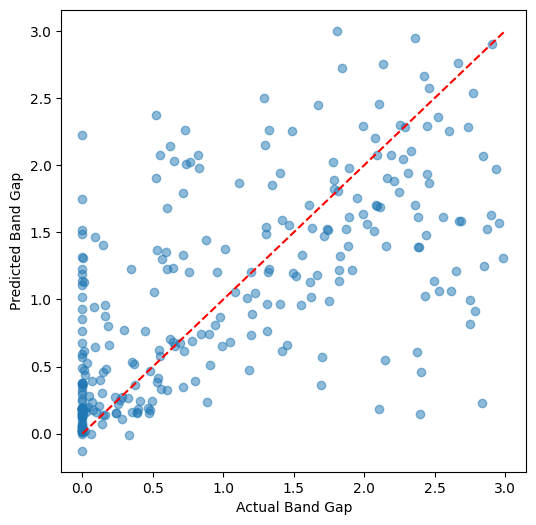

In [158]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(
    targets,
    preds,
    alpha=0.5
)

plt.plot(
    [0,3],
    [0,3],
    'r--'
)

plt.xlabel("Actual Band Gap")
plt.ylabel("Predicted Band Gap")

plt.show()

In [174]:
import pandas as pd

df = pd.read_csv('Dataset Bandgap/bandgap_predictions.csv')
df

,Actual,Predicted,Error
0,2.5290,1.064835,-1.464165
1,0.0923,0.648240,0.555940
2,2.6754,1.584888,-1.090512
3,2.3295,2.106621,-0.222879
4,0.0502,0.283554,0.233354
...,...,...,...
278,0.0000,0.378596,0.378596
279,2.0753,2.200012,0.124712
280,0.7240,0.613667,-0.110333
281,0.0000,0.166999,0.166999
